In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
np.math=math
from scipy.integrate import odeint, solve_ivp
import pysindy as ps
import scienceplots
from pysindy.differentiation import FiniteDifference
plt.style.use('science')
plt.rcParams['font.size'] = 14

# Creación de Datos para SINDy

[0, 0.022034, np.float64(0.9427805029950812), np.float64(2.666585947353145)]


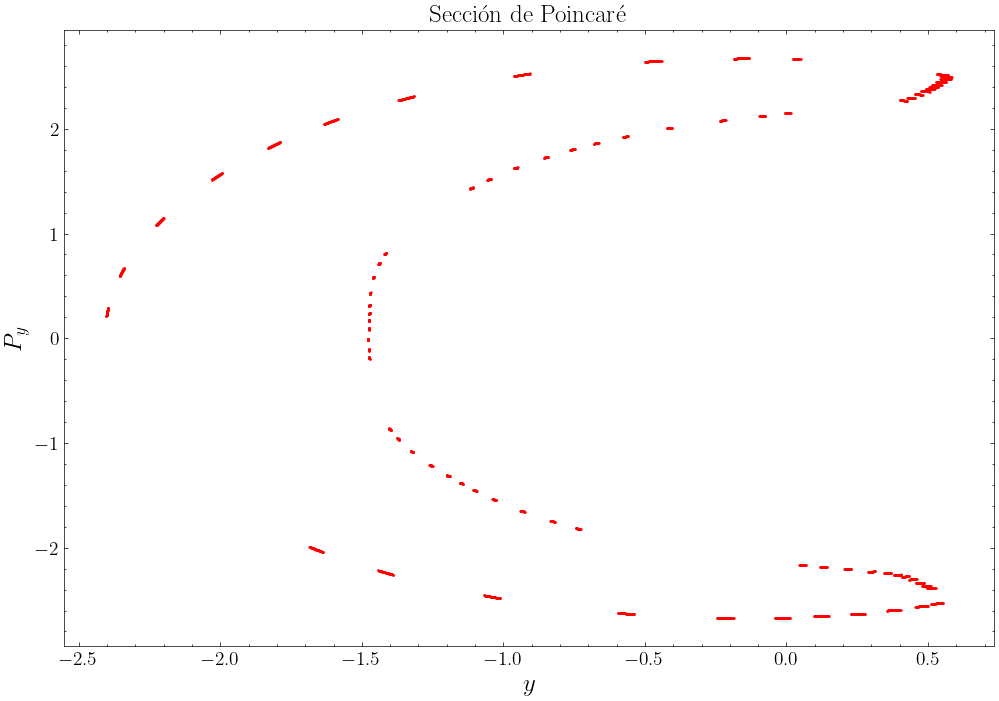

In [22]:
def safe_sqrt(x):
    return np.sqrt(x) if x >= 0 else 0
En = 4
lambda_ = 1/6
def hamilton_eqs(t,R):
    x, y, px, py = R
    dx_dt = px
    dy_dt = py
    dpx_dt =-x-2*lambda_*x*y
    dpy_dt =-y-lambda_*(x**2-y**2)
    return [dx_dt, dy_dt, dpx_dt, dpy_dt]

plt.figure(figsize=(12, 8))
t_span=(0,500)
t_eval=np.linspace(t_span[0],t_span[1],1_000_000)
y_0=0.022034
x_0=0
px_0=safe_sqrt(2*En-y_0**2+(2/3)*lambda_*y_0**3)/3
discriminant=2*En-y_0**2+(2/3)*lambda_*y_0**3-px_0**2
py_0= safe_sqrt(discriminant)
y0=[x_0,y_0,px_0,py_0]
initial_state = [x_0,y_0,px_0,py_0]
sol = solve_ivp(hamilton_eqs, t_span, y0, method='RK45', t_eval=t_eval, rtol=1e-6, atol=1e-8)

poincare_y = []
poincare_py = []

for i in range(len(sol.t) - 1):
    if np.abs(sol.y[0, i]) < 1e-2 and sol.y[2, i] > 0: #x=0 and px>0
        poincare_y.append(sol.y[1, i])
        poincare_py.append(sol.y[3, i])

if poincare_y:
    plt.scatter(poincare_y, poincare_py, s=0.5, color='r', label=f"x_0 = {x_0:.2f}")
print(y0)
plt.xlabel(r"$y$",fontsize=18)
plt.ylabel(r"$P_y$",fontsize=18)
plt.title(r"Sección de Poincaré",fontsize=18)
plt.show()

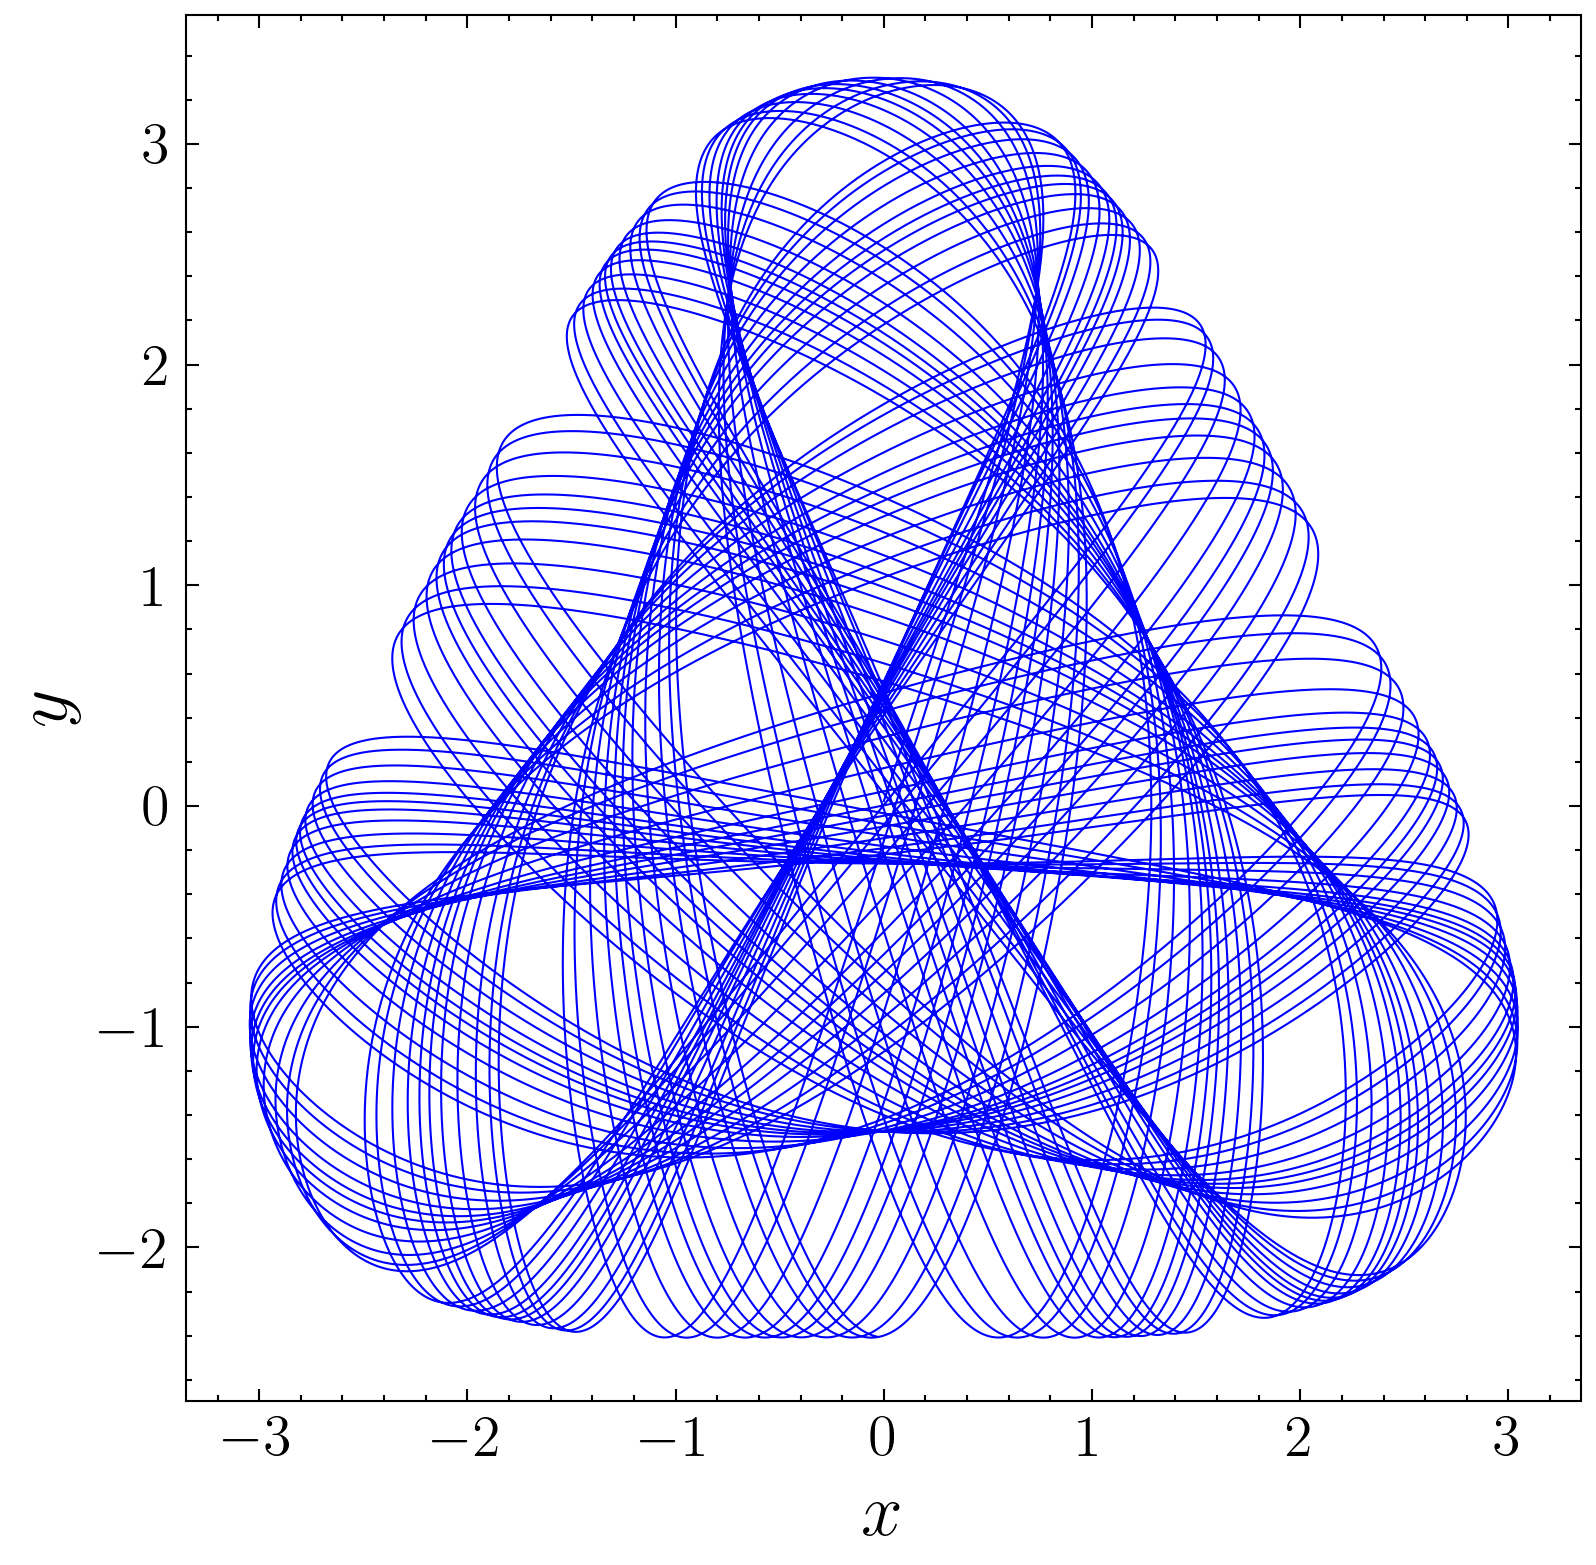

In [23]:
x_arr_test=[sol.y[0],sol.y[1],sol.y[2],sol.y[3]]
plt.figure(figsize=(6,6),dpi=300)
plt.plot(x_arr_test[0],x_arr_test[1],'b-',linewidth=0.5)
plt.xlabel(r"$x$",fontsize=18)
plt.ylabel(r"$y$",fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)

Text(0, 0.5, '$p_y$')

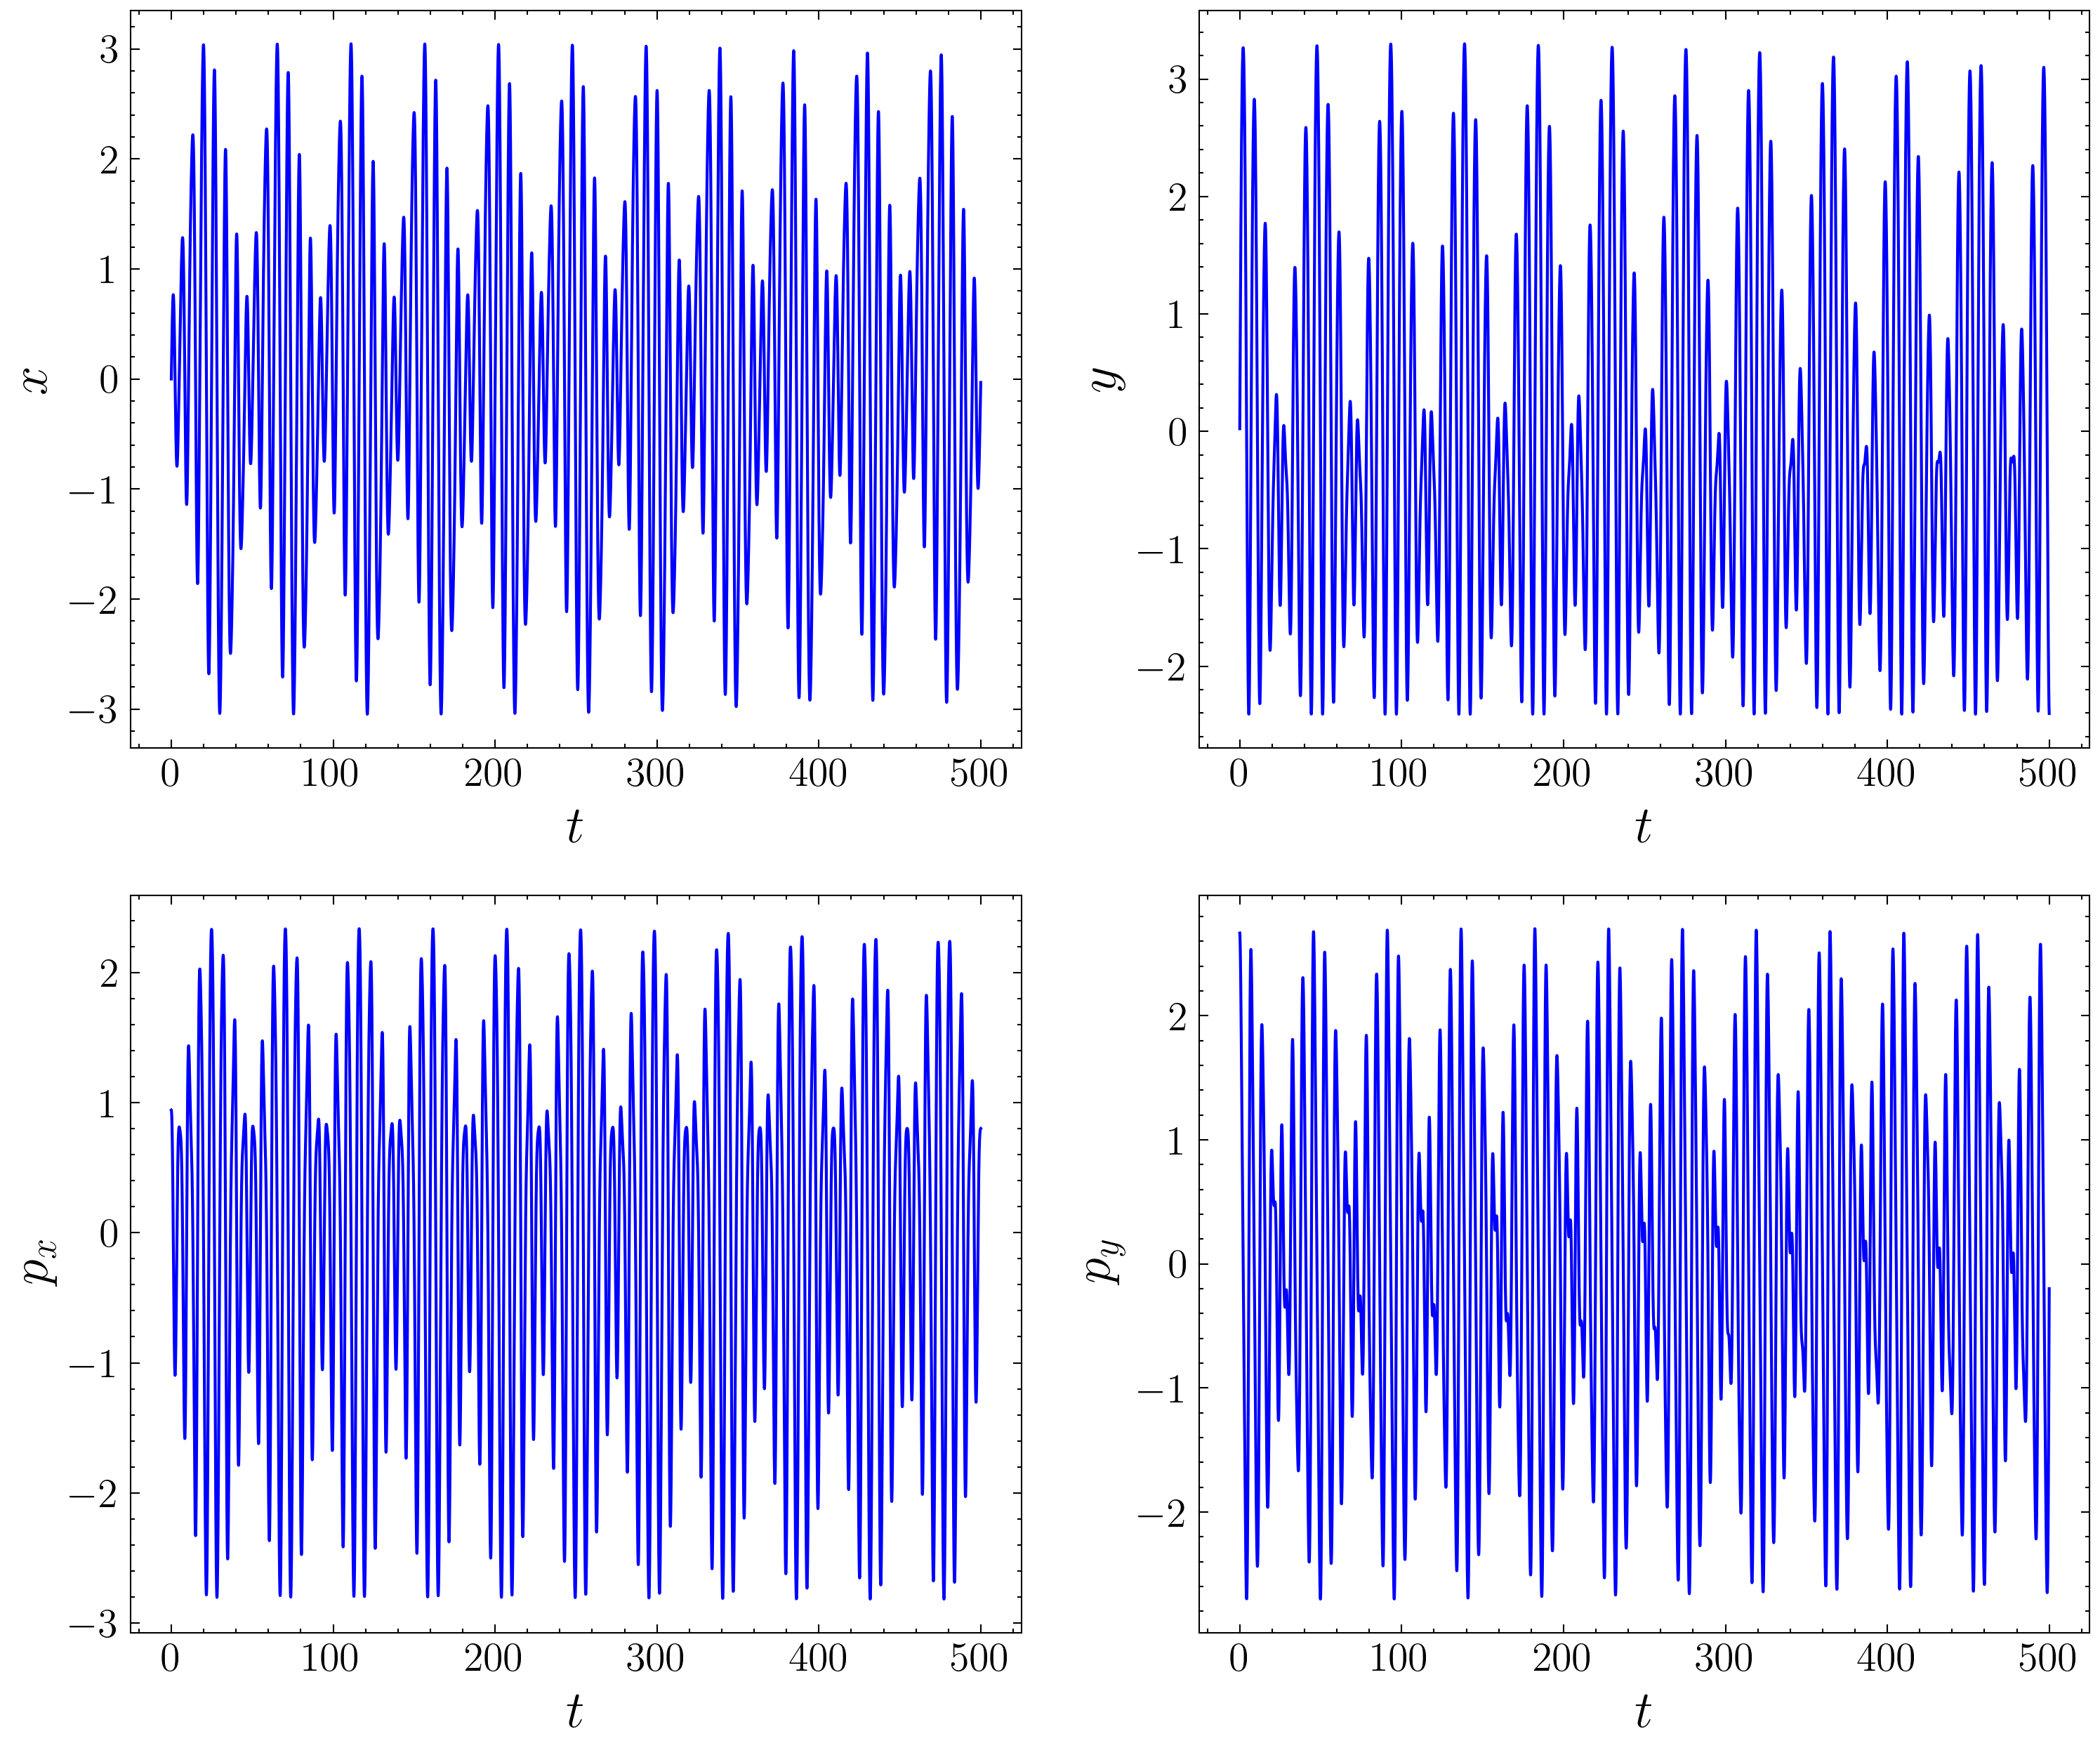

In [24]:
def safe_sqrt(x):
    return np.sqrt(np.clip(x, 0, None))

En = 4
lambda_ = 1/6

def hamilton_eqs(R,t):#Ecuaciones de Movimiento
    x, y, px, py = R
    dRdt=[px
          ,py
          ,-x-2*lambda_*x*y
          ,-y-lambda_*(x**2-y**2)
          ]
    return dRdt

def coefficients(self):
    check_is_fitted(self, "model")
    return self.model.steps[-1][1].coef_

dt=0.005
t = np.arange(0, 500, dt)
x_arr_mine = odeint(hamilton_eqs,initial_state,t)
print('===========================================')
#Gráficas de series temporales#############   
fig, axs = plt.subplots(2, 2, figsize=(12, 10),dpi=300)
axs[0, 0].plot(t, x_arr_mine[:,0], "b")
axs[0, 0].set_xlabel(r"$t$",fontsize=18)
axs[0, 0].set_ylabel(r"$x$",fontsize=18)
axs[0, 1].plot(t, x_arr_mine[:,1], "b")
axs[0, 1].set_xlabel(r"$t$",fontsize=18)
axs[0, 1].set_ylabel(r"$y$",fontsize=18)
axs[1, 0].plot(t, x_arr_mine[:,2], "b")
axs[1, 0].set_xlabel(r"$t$",fontsize=18)
axs[1, 0].set_ylabel(r"$p_x$",fontsize=18)
axs[1, 1].plot(t, x_arr_mine[:,3], "b")
axs[1, 1].set_xlabel(r"$t$",fontsize=18)
axs[1, 1].set_ylabel(r"$p_y$",fontsize=18)


## SINDy

In [25]:
########Calculo de Derivadas##############
fd = FiniteDifference(order=2,drop_endpoints=True) # Create a finite difference object with order 2
dx_arr_mine = fd._differentiate(x_arr_mine, t=dt) # Still pass dt
##############CREAR LIBRERIA DE FUNCIONES#####################
library = ps.PolynomialLibrary(degree=3, include_interaction=True)

##########SINDy###############
threshold =0.01
model = ps.SINDy(optimizer=ps.optimizers.STLSQ(threshold=threshold),
                 feature_library=library,
                 differentiation_method=fd) # Pass the differentiation method here
model.fit(x_arr_mine, t=dt) # Also important to pass dt here

#############Coeficientes del modelo de ajuste#################
coef = model.coefficients()
print(coef[:, :])
print('===========================================')
model.print()
print('===========================================')

[[ 0.          0.          0.          0.99999583  0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.99999584  0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.        ]
 [ 0.         -0.99999442  0.          0.          0.          0.
  -0.33332938  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0

-------------------------------------------------------
azul= Solucion con ecuaciones de movimiento originales
rojo= Solucion con ecuaciones de movimiento de SINDy


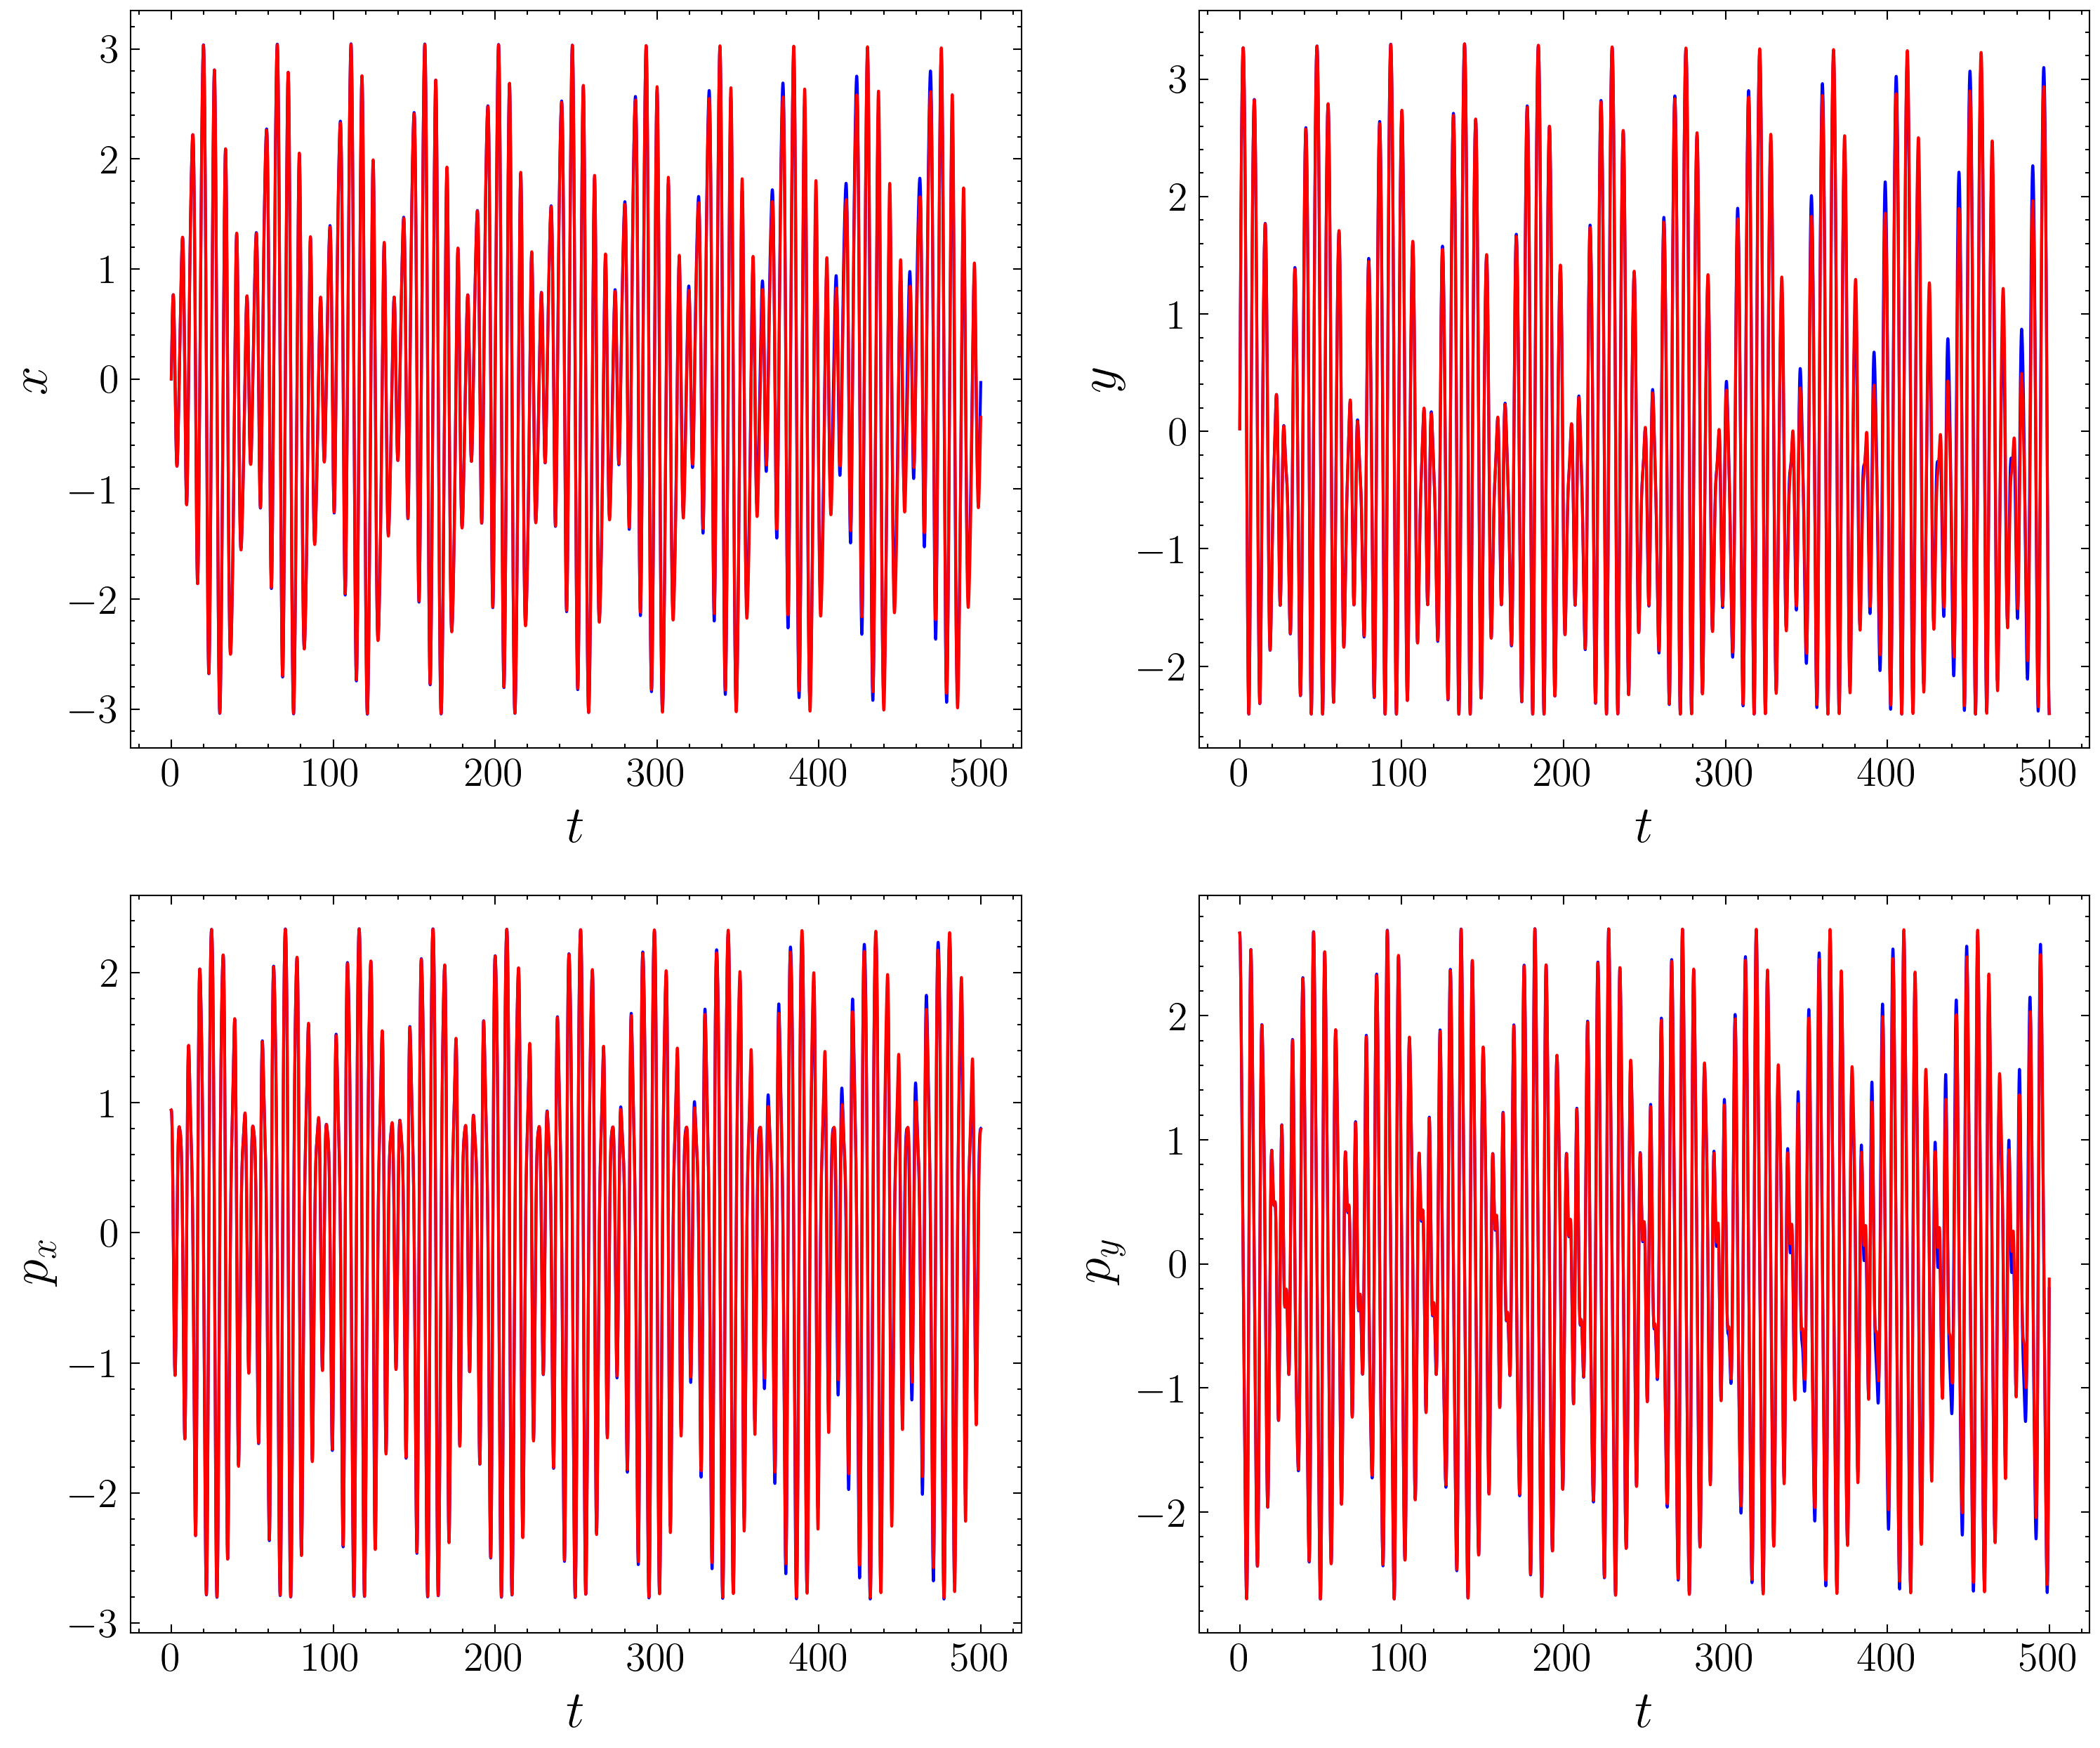

In [26]:
#MODELO SINDY
def eomSINDY(R,t):
    x0,x1,x2,x3=R
    dRdt=[x2,
          x3,
          -x0 + -0.333 * x0 * x1,
          -x1 + -0.167 * x0**2 + 0.167 * x1**2
        ]
    return dRdt
x_arr_sindy = odeint(eomSINDY, initial_state, t)
fig, axs = plt.subplots(2, 2, figsize=(12, 10),dpi=300)
axs[0, 0].plot(t, x_arr_mine[:, 0], "b")
axs[0, 0].plot(t, x_arr_sindy[:, 0], "r")
axs[0, 0].set_xlabel(r"$t$",fontsize=18)
axs[0, 0].set_ylabel(r"$x$",fontsize=18)
axs[0, 1].plot(t, x_arr_mine[:, 1], "b")
axs[0, 1].plot(t, x_arr_sindy[:, 1], "r")
axs[0, 1].set_xlabel(r"$t$",fontsize=18)
axs[0, 1].set_ylabel(r"$y$",fontsize=18)
axs[1, 0].plot(t, x_arr_mine[:, 2], "b")
axs[1, 0].plot(t, x_arr_sindy[:, 2], "r")
axs[1, 0].set_xlabel(r"$t$",fontsize=18)
axs[1, 0].set_ylabel(r"$p_x$",fontsize=18)
axs[1, 1].plot(t, x_arr_mine[:, 3], "b")
axs[1, 1].plot(t, x_arr_sindy[:, 3], "r")
axs[1, 1].set_xlabel(r"$t$",fontsize=18)
axs[1, 1].set_ylabel(r"$p_y$",fontsize=18)
print('-------------------------------------------------------')
print('azul= Solucion con ecuaciones de movimiento originales')
print('rojo= Solucion con ecuaciones de movimiento de SINDy')


Text(0, 0.5, '$\\Delta p_y$')

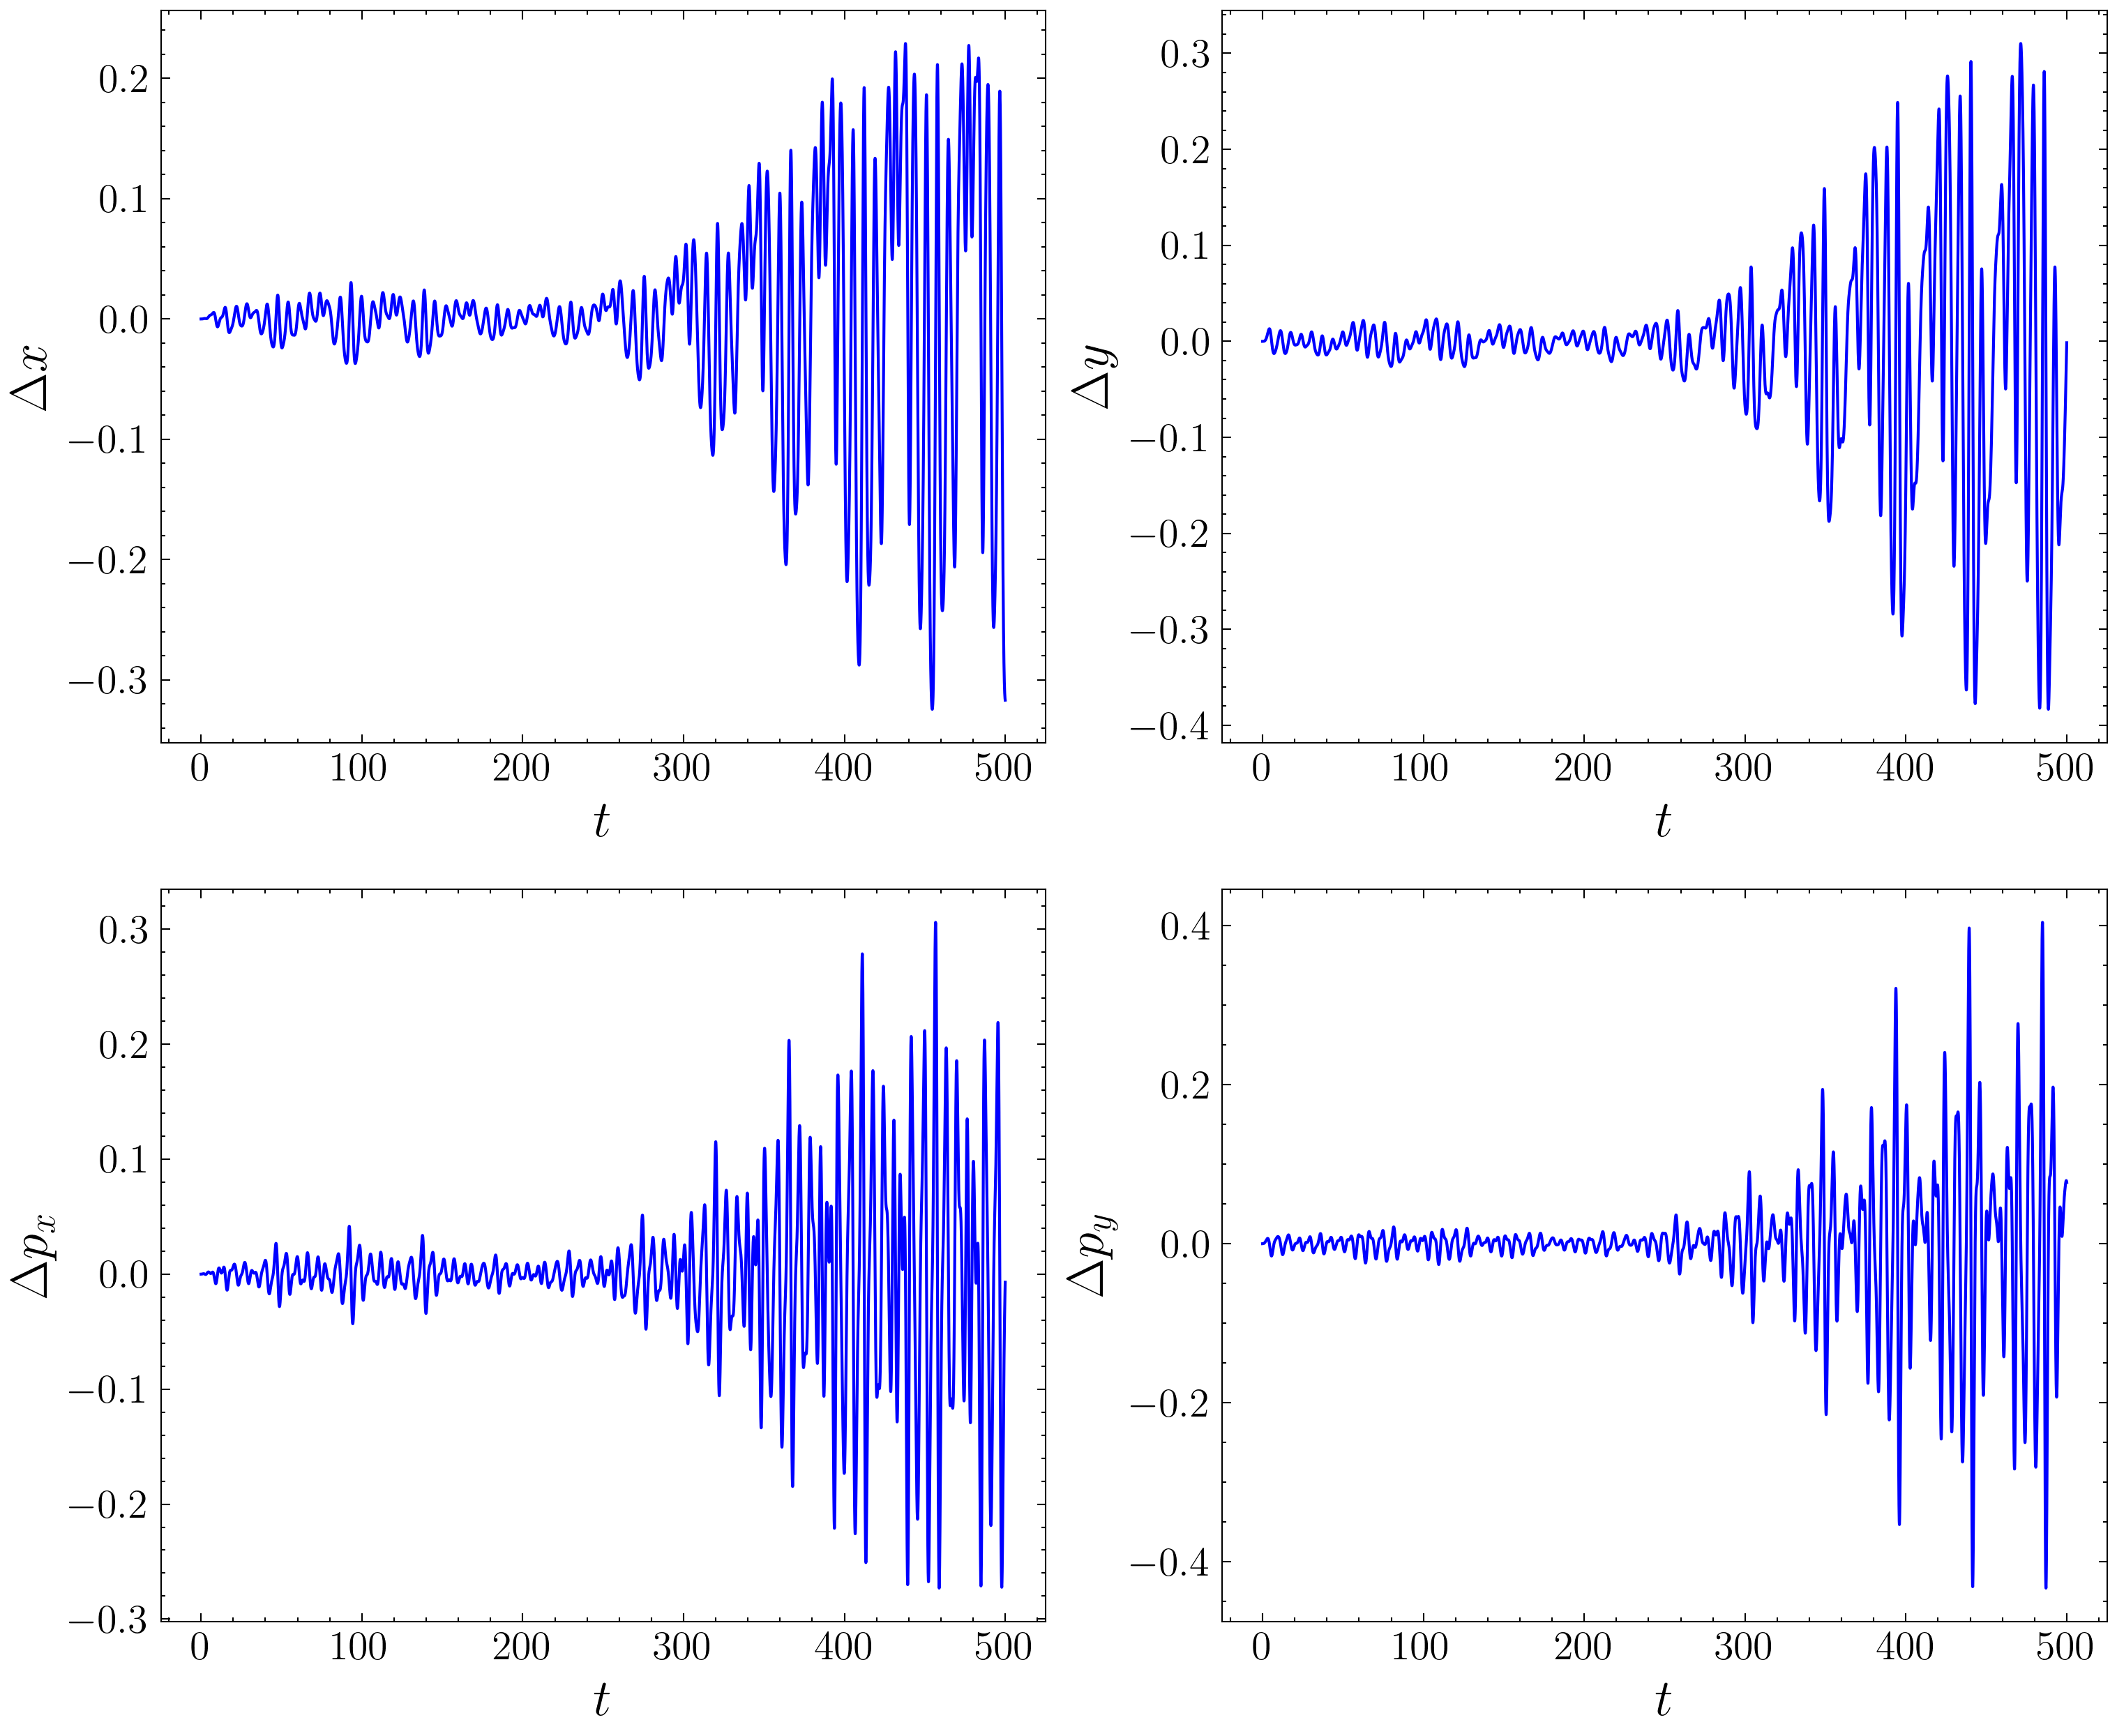

In [27]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10),dpi=300)
axs[0, 0].plot(t, x_arr_sindy[:, 0]-x_arr_mine[:, 0], "b")
axs[0, 0].set_xlabel(r"$t$",fontsize=18)
axs[0, 0].set_ylabel(r"$\Delta x$",fontsize=18)
axs[0, 1].plot(t, x_arr_sindy[:, 1]-x_arr_mine[:, 1], "b")
axs[0, 1].set_xlabel(r"$t$",fontsize=18)
axs[0, 1].set_ylabel(r"$\Delta y$",fontsize=18)
axs[1, 0].plot(t, x_arr_sindy[:, 2]-x_arr_mine[:, 2], "b")
axs[1, 0].set_xlabel(r"$t$",fontsize=18)
axs[1, 0].set_ylabel(r"$\Delta p_x$",fontsize=18)
axs[1, 1].plot(t, x_arr_sindy[:, 3]-x_arr_mine[:, 3], "b")
axs[1, 1].set_xlabel(r"$t$",fontsize=18)
axs[1, 1].set_ylabel(r"$\Delta p_y$",fontsize=18)

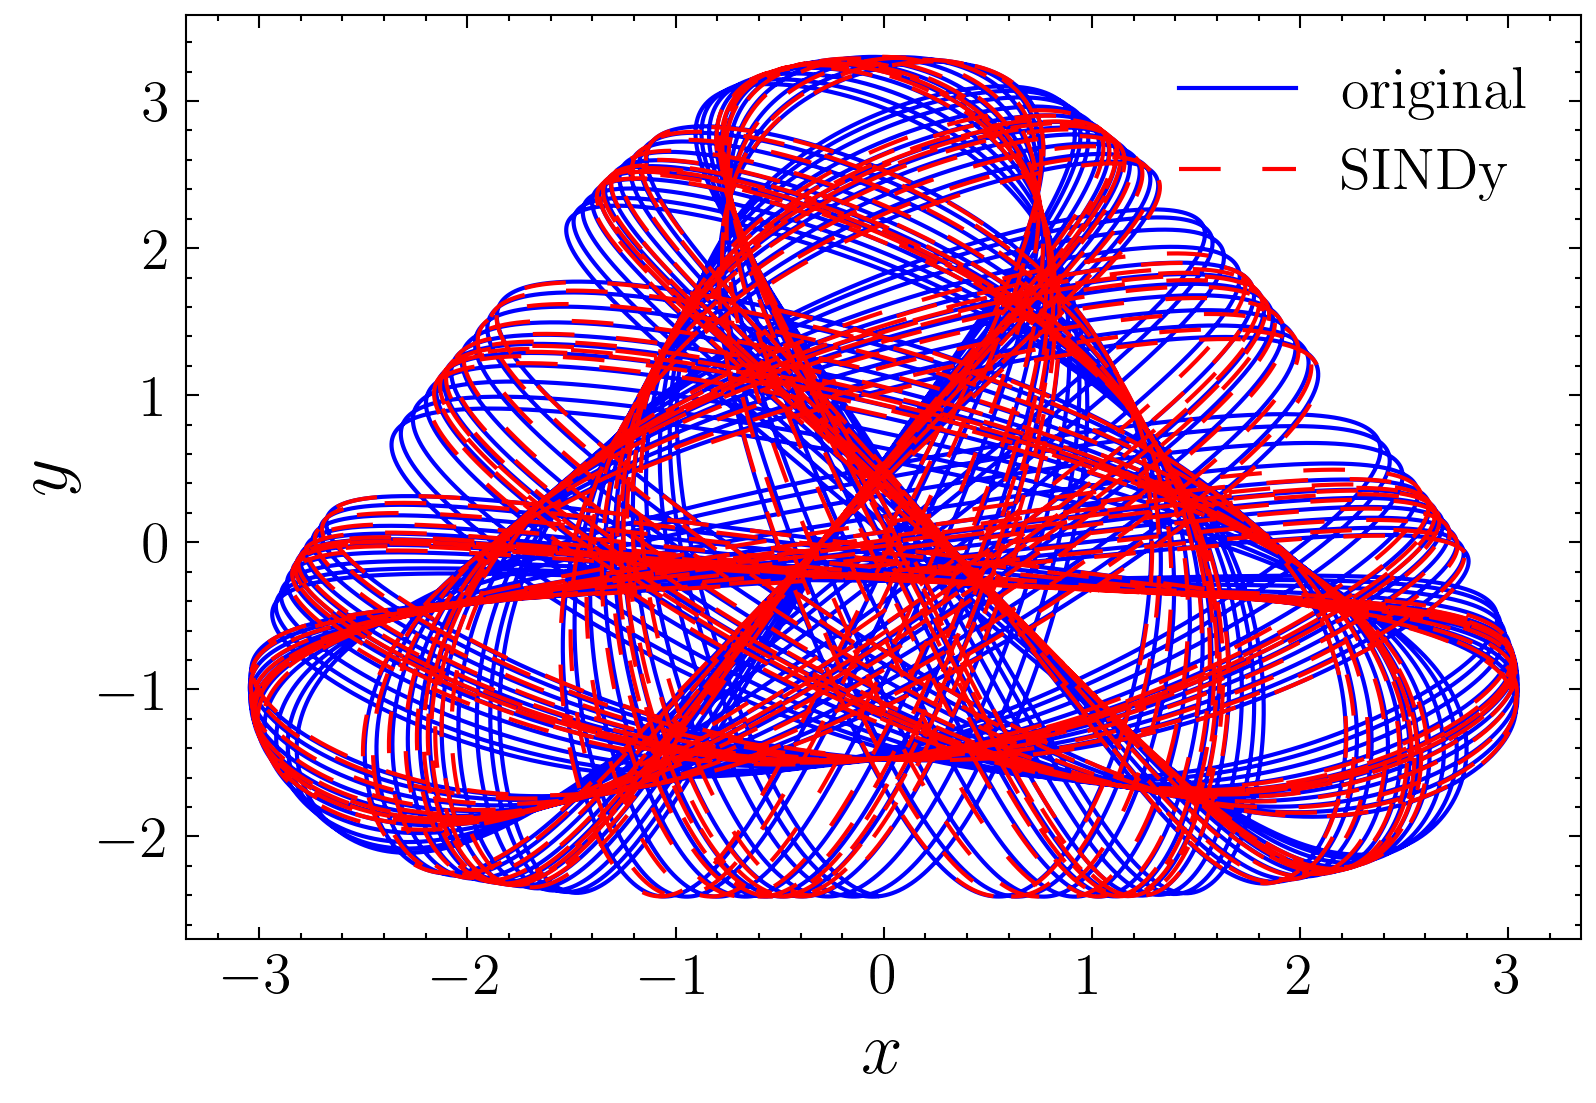

In [28]:
plt.figure(figsize=(6,4),dpi=300)
plt.plot(x_arr_mine[:,0],x_arr_mine[:,1],'b-',label='original')
plt.plot(x_arr_sindy[:,0],x_arr_sindy[:,1],'r',linestyle=(0,(10,10)),label='SINDy')
plt.xlabel(r'$x$',fontsize=18)
plt.ylabel(r'$y$',fontsize=18)
plt.legend()

## Error relativo de los coeficientes de SINDy al variar $dt$

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pysindy as ps
plt.style.use(['science','no-latex'])

In [30]:
En = 4
lambda_ = 1/6
threshold = 0.01
def hamilton_eqs(t,R):
    x, y, px, py = R
    dx_dt = px
    dy_dt = py
    dpx_dt = -x-2*lambda_*x*y
    dpy_dt = -y-lambda_*(x**2-y**2)
    return [dx_dt, dy_dt, dpx_dt, dpy_dt]

# =====================================================
# Librería SINDy
# =====================================================


library = ps.PolynomialLibrary(degree=3, include_interaction=True)

optimizer = ps.STLSQ(threshold=threshold)

# =====================================================
# Solución referencia
# =====================================================
dt_ref = 1e-3
t_max = 100
R0 = [1.2, 0.5, 0.1, -0.2]

t_ref = np.arange(0, t_max, dt_ref)

sol_ref = solve_ivp(
    hamilton_eqs,
    [0, t_max],
    R0,
    t_eval=t_ref
)

X_ref = sol_ref.y.T

model_ref = ps.SINDy(
    feature_library=library,
    optimizer=optimizer
)

model_ref.fit(X_ref, t=dt_ref)

C_orig = model_ref.coefficients()
feature_names = model_ref.get_feature_names()

n_eqs, n_terms = C_orig.shape

# =====================================================
# Barrido en dt
# =====================================================
dt_values = np.linspace(1e-3, 1.2e-3, 25)

equation_errors = np.zeros((n_eqs, n_terms, len(dt_values)))

for k, dt in enumerate(dt_values):

    t_eval = np.arange(0, t_max, dt)

    sol = solve_ivp(
        hamilton_eqs,
        [0, t_max],
        R0,
        t_eval=t_eval
    )

    X = sol.y.T

    model = ps.SINDy(
        feature_library=library,
        optimizer=optimizer
    )

    model.fit(X, t=dt)

    C_sindy = model.coefficients()

    for eq in range(n_eqs):
        for term in range(n_terms):

            denom = np.abs(C_orig[eq, term])

            if denom > 1e-14:
                err = np.abs(C_sindy[eq, term] - C_orig[eq, term]) / denom
            else:
                err = np.abs(C_sindy[eq, term] - C_orig[eq, term])

            equation_errors[eq, term, k] = err


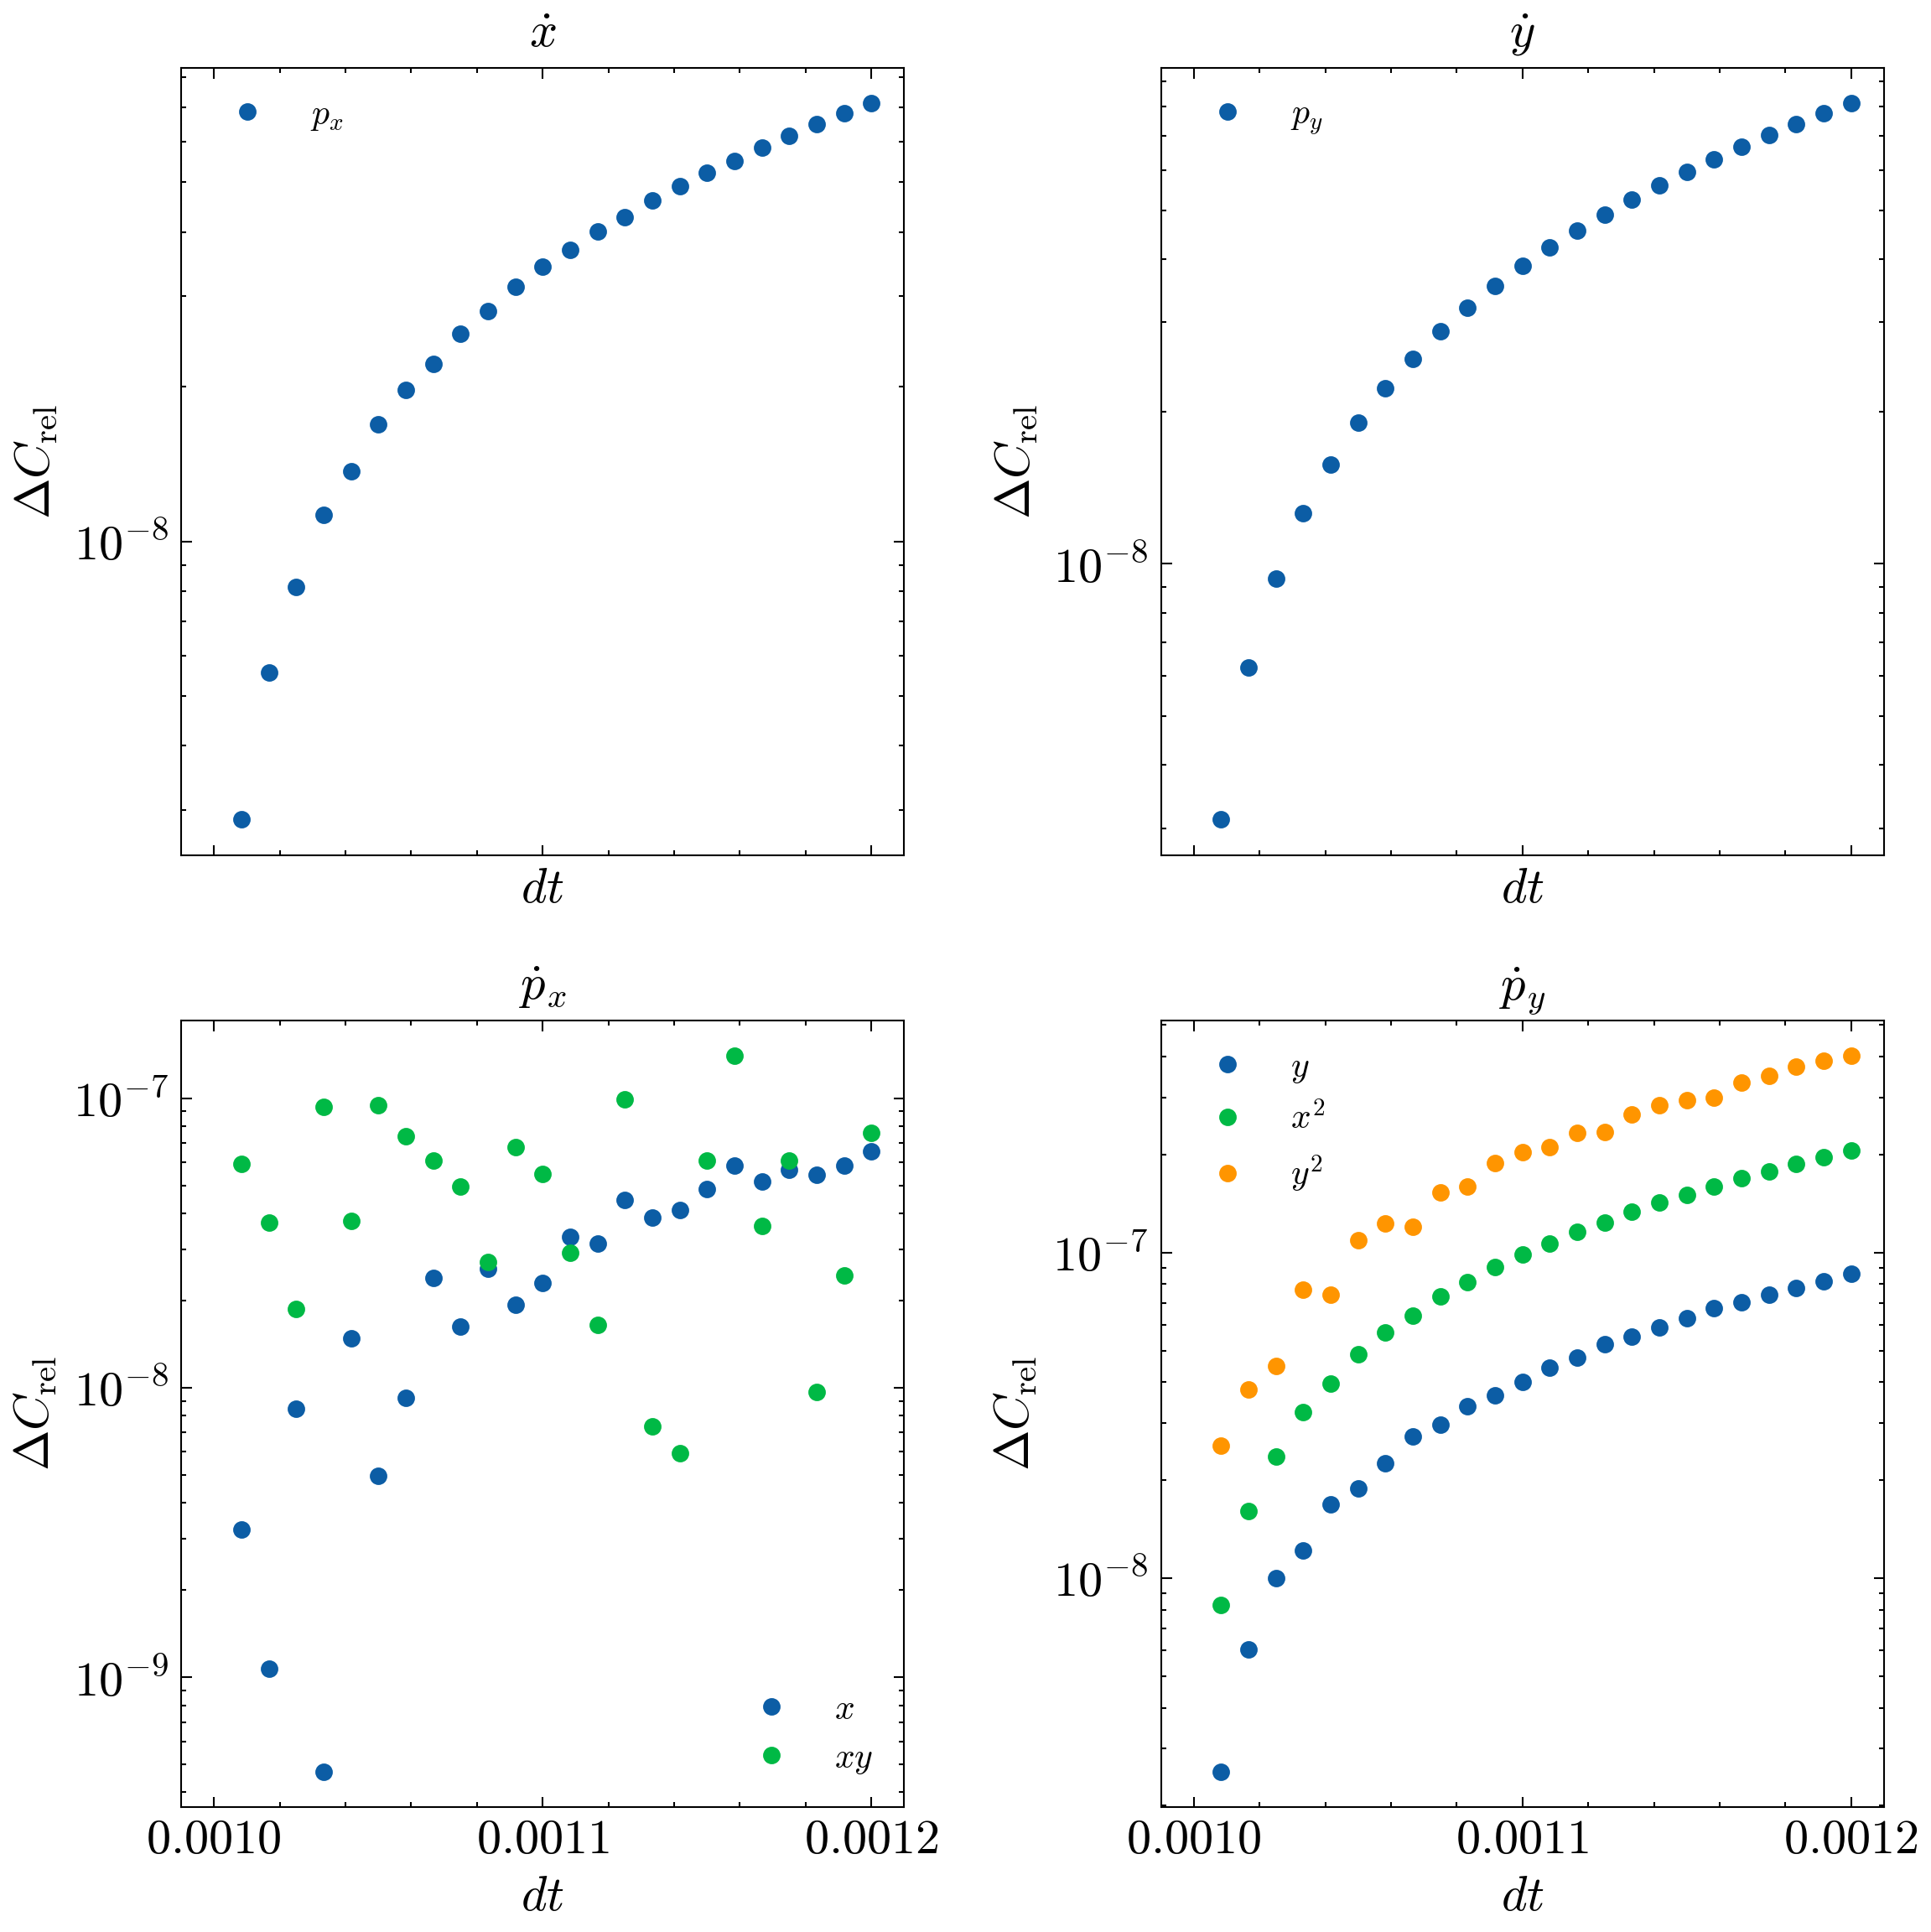

In [31]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8), sharex=True, dpi=300)

eq_labels = [
    r'$\dot{x}$',
    r'$\dot{y}$',
    r'$\dot{p}_x$',
    r'$\dot{p}_y$'
]
label_map = {
    "x0": r"$x$",
    "x1": r"$y$",
    "x2": r"$p_x$",
    "x3": r"$p_y$",
    "x0^2": r"$x^2$",
    "x1^2": r"$y^2$",
    "x0 x1": r"$xy$",
    "x0^3": r"$x^3$",
    "x1^3": r"$y^3$",
    "x0^2 x1": r"$x^2y$",
    "x0 x1^2": r"$x y^2$"
}

for eq in range(4):

    ax = axs.flat[eq]

    for term in range(n_terms):

        # solo mostrar coeficientes importantes
        if np.abs(C_orig[eq, term]) < 1e-8:
            continue

        ax.semilogy(
            dt_values,
            equation_errors[eq, term, :],
            'o',
            linewidth=1.5,
            markersize=4,
            label=label_map.get(feature_names[term], feature_names[term])
        )
    ax.set_title(eq_labels[eq], fontsize=14)
    ax.set_xlabel(r'$dt$')
    ax.set_ylabel(r'$\Delta C_{\rm rel}$')
    ax.legend(fontsize=10)
plt.tight_layout()
plt.show()